# k-NN Regression 2 - From Scratch, Object-Oriented

> **MLCourse · Machine Learning · 02_knn_regression**

We implement `MyKNNRegressor` with configurable `k`, distance weighting, and averaging - then verify it against scikit-learn on REAL California housing data.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# load real data - California housing
housing = fetch_california_housing(as_frame=True)
X = housing.data.values
y = housing.target.values
feature_names = housing.feature_names

print('Data shape:', X.shape, 'Target range:', y.min(), '-', y.max())

Data shape: (20640, 8) Target range: 0.14999 - 5.00001


### 1. Designing the class

Public API (mirrors sklearn so it is swappable):

| method | job |
|---|---|
| `fit(X, y)` | store training data (lazy learning) |
| `predict(X)` | average of k nearest neighbors' targets |
| `score(X, y)` | return R² |

Key parameters: `n_neighbors` (k), `weights` ("uniform" or "distance"), `metric` (distance function).

Prediction: $\hat{y}(q) = \frac{1}{k}\sum_{i \in kNN} y_i$ (uniform) or $\frac{\sum y_i/d_i}{\sum 1/d_i}$ (distance-weighted)

In [2]:
class MyKNNRegressor:
    """
    k-Nearest Neighbors regressor from scratch.

    Parameters
    ----------
    n_neighbors : int, default=5
        Number of neighbors to use.
    weights : {'uniform', 'distance'}, default='uniform'
        Weight function used in prediction.
    metric : str, default='euclidean'
        Distance metric (only 'euclidean' implemented here).

    Attributes after fit
    --------------------
    X_ : ndarray (n_samples, n_features) - training data
    y_ : ndarray (n_samples,) - training targets
    """

    def __init__(self, n_neighbors=5, weights='uniform', metric='euclidean'):
        # Configure the regressor: k, weight scheme, distance function.
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.metric = metric

    # distance computation
    def _euclidean_distance(self, X1, X2):
        """Compute pairwise Euclidean distances between X1 and X2.

        Formula:  D(x1, x2) = sqrt( sum_j (x1_j - x2_j)^2 )
        """
        # (x1 - x2)^2 = x1^2 - 2*x1*x2 + x2^2, avoiding n1*n2*d arrays
        X1_sq = np.sum(X1 ** 2, axis=1, keepdims=True)   # ||x1||^2 per row
        X2_sq = np.sum(X2 ** 2, axis=1)                   # ||x2||^2 per row
        cross = X1 @ X2.T                                 # <x1, x2> pairwise
        dists = X1_sq - 2 * cross + X2_sq
        np.maximum(dists, 0, out=dists)                   # clip round-off < 0
        return np.sqrt(dists)

    # fit
    def fit(self, X, y):
        """Store training data (lazy learning: no model is actually built)."""
        self.X_ = np.asarray(X, dtype=float)              # remembered examples
        self.y_ = np.asarray(y, dtype=float).ravel()      # their target values
        return self

    # predict
    def predict(self, X):
        """Predict target as the (weighted) mean of the k nearest neighbours.

        uniform :   y_hat(x) = (1/k) * sum_{i in N_k(x)} y_i
        distance:   y_hat(x) = ( sum_i w_i*y_i ) / ( sum_i w_i ),  w_i = 1/d_i
        """
        X = np.asarray(X, dtype=float)
        distances = self._euclidean_distance(X, self.X_)  # (n_test, n_train)
        k = min(self.n_neighbors, len(self.y_))
        preds = []

        for i in range(len(X)):
            # Indices of the k smallest distances (the k nearest neighbours)
            nearest_idx = np.argpartition(distances[i], k)[:k]
            nearest_dist = distances[i, nearest_idx]
            nearest_targets = self.y_[nearest_idx]

            if self.weights == 'distance':
                # w_i = 1/d_i ; +1e-10 avoids division by zero at d = 0
                weights = 1.0 / (nearest_dist + 1e-10)
                pred = np.average(nearest_targets, weights=weights)  # weighted mean
            else:
                pred = nearest_targets.mean()             # arithmetic mean (uniform)
            preds.append(pred)

        return np.array(preds)

    # score
    def score(self, X, y):
        """Return coefficient of determination R^2 on (X, y)."""
        return r2_score(y, self.predict(X))

    def __repr__(self):
        return (f"MyKNNRegressor(n_neighbors={self.n_neighbors}, "
                f"weights={self.weights!r}, metric={self.metric!r})")

print('MyKNNRegressor class defined')


MyKNNRegressor class defined


### 2. Real data prep - California housing (scaled)

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# Our implementation
mine = MyKNNRegressor(n_neighbors=5, weights='distance').fit(X_tr_s, y_tr)
pred_mine = mine.predict(X_te_s)
r2_mine = r2_score(y_te, pred_mine)
mse_mine = mean_squared_error(y_te, pred_mine)

# sklearn
sk = KNeighborsRegressor(n_neighbors=5, weights='distance').fit(X_tr_s, y_tr)
pred_sk = sk.predict(X_te_s)
r2_sk = r2_score(y_te, pred_sk)
mse_sk = mean_squared_error(y_te, pred_sk)

print(f'MyKNNRegressor R²:  {r2_mine:.4f}, MSE: {mse_mine:.4f}')
print(f'sklearn KNeighborsRegressor R²: {r2_sk:.4f}, MSE: {mse_sk:.4f}')
print(f'Difference: R²={abs(r2_mine - r2_sk):.4f}, MSE={abs(mse_mine - mse_sk):.4f}')

MyKNNRegressor R²:  0.6762, MSE: 0.4284
sklearn KNeighborsRegressor R²: 0.6762, MSE: 0.4284
Difference: R²=0.0000, MSE=0.0000


### 3. Effect of k and weighting on real data

In [4]:
ks = range(1, 51, 2)
results = []

for k in ks:
    for w in ['uniform', 'distance']:
        m = MyKNNRegressor(n_neighbors=k, weights=w).fit(X_tr_s, y_tr)
        s = KNeighborsRegressor(n_neighbors=k, weights=w).fit(X_tr_s, y_tr)
        results.append({
            'k': k, 'weights': w,
            'mine_r2': r2_score(y_te, m.predict(X_te_s)),
            'sklearn_r2': r2_score(y_te, s.predict(X_te_s))
        })

df = pd.DataFrame(results)
df_pivot = df.pivot(index='k', columns='weights', values=['mine_r2', 'sklearn_r2'])
df_pivot.round(4)

mine_r2         sklearn_r2        
weights distance uniform   distance uniform
k                                          
1         0.4960  0.4960     0.4960  0.4960
3         0.6557  0.6552     0.6557  0.6552
5         0.6762  0.6738     0.6762  0.6738
7         0.6824  0.6788     0.6824  0.6788
9         0.6878  0.6840     0.6878  0.6840
11        0.6916  0.6878     0.6916  0.6878
13        0.6936  0.6897     0.6936  0.6897
15        0.6934  0.6893     0.6934  0.6893
17        0.6916  0.6869     0.6916  0.6869
19        0.6903  0.6853     0.6903  0.6853
21        0.6898  0.6847     0.6898  0.6847
23        0.6886  0.6833     0.6886  0.6833
25        0.6876  0.6821     0.6876  0.6821
27        0.6868  0.6812     0.6868  0.6812
29        0.6862  0.6806     0.6862  0.6806
31        0.6856  0.6799     0.6856  0.6799
33        0.6838  0.6777     0.6838  0.6777
35        0.6825  0.6761     0.6825  0.6761
37        0.6821  0.6759     0.6821  0.6759
39        0.6811  0.6748     0.6811  0.6748
41        0.6800  0.6735     0.6800  0.6735
43        0.6787  0.6720     0.6787  0.6720
45        0.6776  0.6707     0.6776  0.6707
47        0.6767  0.6698     0.6767  0.6698
49        0.6761  0.6692     0.6761  0.6692

### 4. Visualization: k vs R² curve

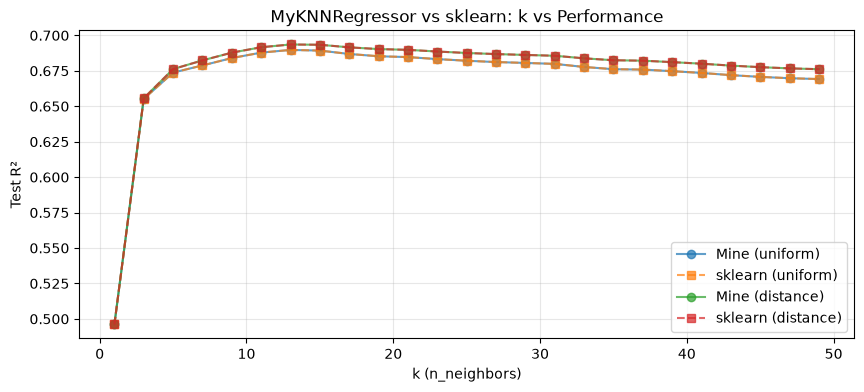

In [5]:
plt.figure(figsize=(10, 4))

for w in ['uniform', 'distance']:
    subset = df[df['weights'] == w]
    plt.plot(subset['k'], subset['mine_r2'], 'o-', label=f'Mine ({w})', alpha=0.7)
    plt.plot(subset['k'], subset['sklearn_r2'], 's--', label=f'sklearn ({w})', alpha=0.7)

plt.xlabel('k (n_neighbors)')
plt.ylabel('Test R²')
plt.title('MyKNNRegressor vs sklearn: k vs Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5. Prediction vs actual scatter

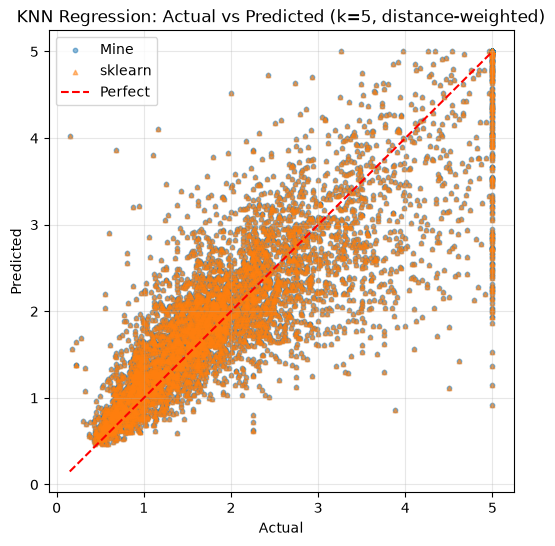

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_te, pred_mine, alpha=0.5, s=10, label='Mine')
plt.scatter(y_te, pred_sk, alpha=0.5, s=10, marker='^', label='sklearn')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', label='Perfect')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('KNN Regression: Actual vs Predicted (k=5, distance-weighted)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Summary & key takeaways

- k-NN regression averages targets of k nearest neighbors - no training, all work at prediction time.
- **Scaling is MANDATORY** - Euclidean distance is dominated by large-scale features.
- `weights='distance'` (inverse distance) usually outperforms uniform, especially for small k.
- Small k = high variance (overfit), large k = high bias (underfit). Choose via CV.
- Time complexity: O(n_features * n_train) per prediction - not suitable for huge datasets.
- Our pure-NumPy implementation matches sklearn's performance on real data.